# G3 — ViT 진단 일반화 (DeiT-Tiny / CIFAR100 / W3)

G2가 생략한 **단일층 진단①②**을 ViT에서 채운다 (G1의 CNN들과 같은 두 축):
- **① 단기proxy**: `normHd2`(‖Hδ‖²)가 단일층 short recovery를 예측하나? (부분상관, size N 통제)
- **① 역전**: short-opt 층 ≠ long-opt 층? `inv = 1-ρ(short,long)` + **bootstrap CI·noise floor**(G1보다 강한 통계 backing, S1.2 게이트 이식)

payoff⑤는 **G2에서 했음** → G3는 진단 전용(끝에서 G2 payoff를 불러 전체 ViT 행 조립).

⚠️ 224 입력이라 단일층 sweep이 무겁다(50층 × seeds × long_t, ~2h A100). 층별 증분저장으로 크래시 안전. **현상 재현이지 selector recipe 아님.**
엔진은 generic — `recover_subset`/`proxy_scores`가 Linear에도 그대로 동작(timm fused attention만 끔, HVP 이중backward용).

In [1]:
# --- Colab 셋업 ---
import os
REPO = '/content/26_Capstone'
if not os.path.isdir(REPO):
    !git clone -q https://github.com/u-nsiq/26_Capstone.git {REPO}
else:
    !git -C {REPO} pull -q
os.chdir(REPO)
!pip install -q -r requirements.txt
import torch; print('torch', torch.__version__, '| cuda', torch.cuda.is_available())

torch 2.11.0+cu128 | cuda True


In [2]:
# --- 엔진 + Drive + 경로 ---
from qat_engine import *
import numpy as np, json, timm
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

try:
    from google.colab import drive; drive.mount('/content/drive')
    ART = '/content/drive/MyDrive/26_Capstone'
except Exception:
    ART = './_local_art'
os.makedirs(f'{ART}/checkpoints', exist_ok=True); os.makedirs(f'{ART}/outputs/G1', exist_ok=True)
N_BITS = 3
print('device', DEVICE)

Mounted at /content/drive
device cuda


In [3]:
# --- ViT FP: DeiT-Tiny pretrained + AdamW finetune (224 upsample CIFAR100, 캐시) --- (G2와 동일)
IMG = 224
imnorm = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))   # ImageNet norm (pretrained 일관)
tf_tr = transforms.Compose([transforms.Resize(IMG), transforms.RandomCrop(IMG, padding=16),
                            transforms.RandomHorizontalFlip(), transforms.ToTensor(), imnorm])
tf_te = transforms.Compose([transforms.Resize(IMG), transforms.ToTensor(), imnorm])
DR = f'{ART}/data'
tr_set = datasets.CIFAR100(DR, train=True,  download=True, transform=tf_tr)
te_set = datasets.CIFAR100(DR, train=False, download=True, transform=tf_te)
ca_set = Subset(datasets.CIFAR100(DR, train=True, download=True, transform=tf_te), list(range(512)))
train224 = DataLoader(tr_set, batch_size=128, shuffle=True,  num_workers=2, drop_last=True)
val224   = DataLoader(te_set, batch_size=128, shuffle=False, num_workers=2)
calib224 = DataLoader(ca_set, batch_size=64,  shuffle=False, num_workers=2)

VCKPT = f'{ART}/checkpoints/deit_tiny_cifar100_fp.pt'
vit = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=100).to(DEVICE)
if os.path.exists(VCKPT):
    vit.load_state_dict(torch.load(VCKPT, map_location='cpu')); vit = vit.to(DEVICE)
    print('ViT FP 캐시 로드')
else:
    EPOCHS = 5
    print(f'ViT finetune (AdamW, {EPOCHS}ep, 224)...')
    opt = torch.optim.AdamW(vit.parameters(), lr=1e-4, weight_decay=0.05)
    crit = nn.CrossEntropyLoss()
    for ep in range(EPOCHS):
        vit.train()
        for x, y in train224:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss = crit(vit(x), y); loss.backward(); opt.step()
        a, _ = evaluate_full(vit, val224, DEVICE); print(f'  ep{ep} val acc {a:.2f}')
    torch.save(vit.state_dict(), VCKPT)
vit.eval()
fp_acc, _ = evaluate_full(vit, val224, DEVICE)
print(f'ViT FP acc {fp_acc:.2f}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT FP 캐시 로드
ViT FP acc 80.94


In [4]:
# --- fused_attn off + PTQ gap + proxy(normHd2) ---  (HVP 이중backward용; G2와 동일)
_noff = 0
for _m in vit.modules():
    if hasattr(_m, 'fused_attn'):
        _m.fused_attn = False; _noff += 1
print(f'fused_attn off: {_noff} attn modules (HVP 이중backward 가능 / 수치 동일)')
qm = make_ptq_model(vit, N_BITS, DEVICE)
ptq_acc, L_PTQ = evaluate_full(qm, val224, DEVICE)
layers = list_quant_layers(qm)
costs = get_layer_costs(qm, layers)
scores = proxy_scores(qm, vit, N_BITS, calib224, layers=layers, n_batches=8)
print(f'ViT: {len(layers)} quant layers | FP {fp_acc:.2f} -> PTQ {ptq_acc:.2f} (gap {fp_acc-ptq_acc:.2f})')
if ptq_acc < max(5.0, 0.10 * fp_acc):
    print(f'  [W3-ViT-COLLAPSE] ptq_acc={ptq_acc:.2f} 낮음 → 진단 상대순위는 유효하나 절대 recovery 작을 수 있음.')

fused_attn off: 12 attn modules (HVP 이중backward 가능 / 수치 동일)
ViT: 50 quant layers | FP 80.94 -> PTQ 17.04 (gap 63.90)


In [6]:
# --- 단일층 진단 sweep (short 30 / long 800) — 무거움(50층×seeds×long_t @224). 층별 증분저장(재개 가능) ---
SHORT_T = 30; LONG_T = 800; SEEDS = (0, 1, 2)   # 빡빡하면 LONG_T=500(~1.5h)·SEEDS=(0,1). 800=G1-정합(~2-2.5h A100).
eval_at = (SHORT_T, LONG_T)
DIAG_JSONL = f'{ART}/outputs/G1/g3_vit_single_w{N_BITS}.jsonl'   # SEEDS 바꿔 재개하려면 이 파일 삭제(층별 seed수 캐시됨)
import time as _time
done = {}
if os.path.exists(DIAG_JSONL):
    for line in open(DIAG_JSONL):
        d = json.loads(line); done[d['L']] = [{int(t): v for t, v in p.items()} for p in d['per']]
    print(f'재개: {len(done)}/{len(layers)} 층 캐시됨')
single_per = {}
for i, L in enumerate(layers):
    if L in done:
        single_per[L] = done[L]; continue
    t0 = _time.time()
    per = []
    for s in SEEDS:
        res = recover_subset(vit, N_BITS, [L], train224, val224, steps=LONG_T, eval_at=eval_at, seed=s, device=DEVICE)
        per.append({t: float(L_PTQ - res[t]['loss']) for t in eval_at})   # res 1회/seed → short·long 함께 추출(중복 run X)
    single_per[L] = per
    with open(DIAG_JSONL, 'a') as f:
        f.write(json.dumps({'L': L, 'per': [{str(t): v for t, v in p.items()} for p in per]}) + '\n')
    if i % 3 == 0 or i == len(layers) - 1:
        print(f'  [{i+1:2d}/{len(layers)}] {L:<26} short={single_per[L][0][SHORT_T]:.4f} long={single_per[L][0][LONG_T]:.4f}  ({_time.time()-t0:.0f}s)')
print('single-layer sweep done')

single_R = {L: {t: float(np.mean([p[t] for p in single_per[L]])) for t in eval_at} for L in layers}
nh   = [scores[L]['normHd2'] for L in layers]
rs_s = [single_R[L][SHORT_T] for L in layers]
rs_l = [single_R[L][LONG_T]  for L in layers]
Nvec = [costs[L] for L in layers]
corr_raw   = spearman(nh, rs_s)
corr_partN = partial_spearman(nh, rs_s, Nvec)
inv_1mrho  = 1.0 - spearman(rs_s, rs_l)
short_opt  = max(layers, key=lambda L: single_R[L][SHORT_T])
long_opt   = max(layers, key=lambda L: single_R[L][LONG_T])
nS = min(len(single_per[L]) for L in layers)    # 캐시 seed수와 SEEDS 불일치(재개)해도 IndexError 안 나게 min으로 clamp
if nS != len(SEEDS): print(f'  ⚠ seed수 불일치(캐시 {nS} vs SEEDS {len(SEEDS)}) → {nS}개로 분석. 바꾸려면 위 jsonl 삭제.')
short_ps = [[single_per[L][si][SHORT_T] for L in layers] for si in range(nS)]   # [seed][layer]
long_ps  = [[single_per[L][si][LONG_T]  for L in layers] for si in range(nS)]
boot = bootstrap_inversion(short_ps, long_ps)        # 점추정+95%CI (S1.2 게이트 이식)
_nfs = [v for v in (noise_floor_matched(short_ps), noise_floor_matched(long_ps)) if not np.isnan(v)]
noise_inv = max(_nfs) if _nfs else float('nan')      # short·long 양 arm floor의 max (S1.2 real_inversion과 동일, G3-4)
thr = 1.96 / (len(layers) - 1) ** 0.5
print(f'\nDeiT-Tiny W{N_BITS} 진단 (n={len(layers)}층, seeds={nS}, short={SHORT_T}/long={LONG_T})')
print(f'  short-R spread : std={np.std(rs_s):.4f} [{min(rs_s):.4f},{max(rs_s):.4f}]  (0 근처로 뭉치면 rank=noise 주의)')
print(f'  normHd2->short : raw={corr_raw:+.2f}  partN={corr_partN:+.2f}  (유의선|rho|>{thr:.2f}) -> {"유의*" if abs(corr_partN)>thr else "약신호~"}')
print(f'  inversion 1-rho={inv_1mrho:+.3f}  CI95=[{boot["ci_lo"]:+.3f},{boot["ci_hi"]:+.3f}]  noise(max)={noise_inv:+.3f} -> {"역전 신호(CI_lo>noise)" if boot["ci_lo"] > noise_inv else "미확정"}')
print(f'  short_opt = {short_opt}')
print(f'  long_opt  = {long_opt}  {"<- 다름=역전(near-conv t=800)" if short_opt != long_opt else "<- 같음"}')

재개: 16/50 층 캐시됨
  [19/50] blocks.4.attn.proj         short=0.4230 long=1.6857  (360s)
  [22/50] blocks.5.attn.qkv          short=0.3023 long=1.5686  (359s)
  [25/50] blocks.5.mlp.fc2           short=0.3968 long=1.5532  (359s)
  [28/50] blocks.6.mlp.fc1           short=0.3929 long=1.5228  (362s)
  [31/50] blocks.7.attn.proj         short=0.1075 long=1.0656  (365s)
  [34/50] blocks.8.attn.qkv          short=0.1202 long=1.0715  (363s)
  [37/50] blocks.8.mlp.fc2           short=0.0391 long=0.6071  (359s)
  [40/50] blocks.9.mlp.fc1           short=0.0856 long=0.6842  (358s)
  [43/50] blocks.10.attn.proj        short=0.0370 long=0.5683  (359s)
  [46/50] blocks.11.attn.qkv         short=0.0478 long=0.6553  (359s)
  [49/50] blocks.11.mlp.fc2          short=0.0253 long=0.4725  (360s)
  [50/50] head                       short=0.1920 long=0.8796  (358s)
single-layer sweep done

DeiT-Tiny W3 진단 (n=50층, seeds=3, short=30/long=800)
  short-R spread : std=0.2561 [0.0247,1.4072]  (0 근처로 뭉치면 rank=nois

saved g3_vit_diagnostic
DeiT-Tiny / W3  (FP 80.94, PTQ 17.04, gap 63.90)
  [진단·G3] normHd2->short partN=+0.90 * | inv=+0.046 CI=[+0.044,+0.052] (noise +0.002)
  [적용·G2] full=70.84 | normHd2-topk=65.28(25%) vs rand(avg)=60.98


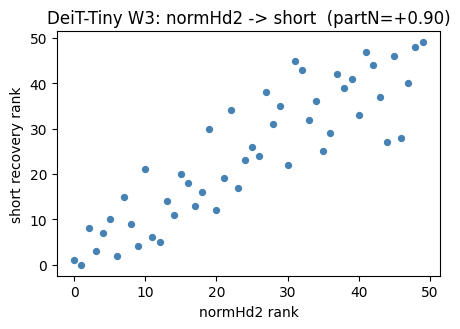

In [7]:
# --- 진단 저장(먼저) + 전체 ViT 행 조립 (진단 G3 + payoff G2) + 그림 ---
import matplotlib.pyplot as plt
out = dict(model='deit_tiny_patch16_224', n_layers=len(layers), n_bits=N_BITS,
           short_t=SHORT_T, long_t=LONG_T, n_seeds=nS,
           fp_acc=float(fp_acc), ptq_acc=float(ptq_acc), gap=float(fp_acc - ptq_acc),
           corr_short_raw=float(corr_raw), corr_short_partN=float(corr_partN),
           inv_1mrho=float(inv_1mrho), inv_ci=[float(boot['ci_lo']), float(boot['ci_hi'])],
           noise_inv=float(noise_inv), short_opt=short_opt, long_opt=long_opt,
           single_R={L: single_R[L] for L in layers})
json.dump(out, open(f'{ART}/outputs/G1/g3_vit_diagnostic_w{N_BITS}.json', 'w'), indent=2)  # 진단은 *먼저* 저장(payoff 조립 실패와 무관, G3-8)
print('saved g3_vit_diagnostic')

print(f'DeiT-Tiny / W{N_BITS}  (FP {fp_acc:.2f}, PTQ {ptq_acc:.2f}, gap {fp_acc-ptq_acc:.2f})')
print(f'  [진단·G3] normHd2->short partN={corr_partN:+.2f} {"*" if abs(corr_partN) > thr else "~"} | inv={inv_1mrho:+.3f} CI=[{boot["ci_lo"]:+.3f},{boot["ci_hi"]:+.3f}] (noise {noise_inv:+.3f})')
g2p = f'{ART}/outputs/G1/g2_vit_bridge_w{N_BITS}.json'
try:                                            # G2 payoff는 보조 — 없거나 포맷 달라도 진단은 이미 저장됨
    g2 = json.load(open(g2p)); p = g2['payoff']; T = int(p['t_evals'][-1])
    gi = lambda d: {int(t): v for t, v in d.items()}
    tk = gi(p['acc']['normHd2-topk'])[T]; rr = gi(p['acc']['random(avg)'])[T]; flv = gi(p['acc']['full'])[T]
    tkp = p['param_ratio']['normHd2-topk'] * 100
    print(f'  [적용·G2] full={flv:.2f} | normHd2-topk={tk:.2f}({tkp:.0f}%) vs rand(avg)={rr:.2f}')
except (FileNotFoundError, KeyError) as e:
    print(f'  [적용·G2] payoff 생략 ({type(e).__name__}) — G2 json 확인. 진단 결과는 저장됨.')

xr = np.argsort(np.argsort(nh)); yr = np.argsort(np.argsort(rs_s))   # 순위 산점 (spearman 시각화)
plt.figure(figsize=(4.6, 3.4))
plt.scatter(xr, yr, s=18, color='steelblue')
plt.xlabel('normHd2 rank'); plt.ylabel('short recovery rank')
plt.title(f'DeiT-Tiny W{N_BITS}: normHd2 -> short  (partN={corr_partN:+.2f})')
plt.tight_layout(); plt.savefig(f'{ART}/outputs/G1/g3_vit_corr.png', dpi=120); plt.show()

## G3 해석 (ViT 진단 일반화)

**G2(적용 payoff) + G3(진단)으로 ViT 그림 완성** — 이제 ResNet18(S1.2)과 같은 두 축을 ViT에서도 본다.

읽는 법:
- **`normHd2->short partN`이 유의선(n=50이면 |ρ|>≈0.28)을 넘으면(`*`)** → 단기proxy ‖Hδ‖²가 ViT 단일층 short recovery도 예측 → **진단 일반화**. 작은 양수(`~`)는 약신호.
- **`inv` CI 하한 > noise** → short-opt 층 ≠ long-opt 층 = **역전 *신호*가 ViT에서도**. (G1과 달리 G3는 부트 CI + noise floor(short·long max, S1.2와 동일)로 정량 보조.)
  - inv≈0(CI가 noise 못 넘음)이면 → **역전은 conv-특이적**일 수 있음(이것도 정직한 발견: "단기proxy는 일반화하나 역전은 아키텍처 의존").

⚠️ 한계(정직):
- **단일 ViT 모델(DeiT-Tiny)** — 일반화 *확정*이 아니라 아키텍처-확장 신호.
- **게이트는 부트 CI vs noise floor만** — S1.2 real_inversion의 rank_stability·breakdown 추가 게이트는 미적용 → "정성 게이트"(확정 아님).
- **long_t=800은 224 비용상 'near-conv' 근사** (ViT 수렴 timescale 미측정, 절대 수렴앵커 아님).
- **recovery=SGD momentum-0** (연구 프로토콜 일관). G2서 full이 17→71로 회복돼 신호 살아있음 확인됨.
- **seeds=3 → 부트 CI·noise floor 넓고 거침**(S1.2는 5; A100 여유면 SEEDS=(0,1,2,3,4)로). `short-R spread`가 0 근처로 뭉치면 rank가 noise일 수 있으니 같이 볼 것.

→ 발표: G2(payoff 재현)+G3(진단 재현)을 합쳐 **"ViT에서도 단기proxy 예측(+역전 신호)이 (정도차 있게) 재현"**. CNN 2개(G1)와 함께 = 모델/아키텍처 축 일반화.